## UWGB COMP SCI 464-0800 – MNIST Dataset Exploration Assignment

In the following assignment, I will explore the MNIST dataset – leveraging different neural network and deep learning techniques to work with the dataset – including simple neural networks (traditional Machine Learning) and Convolutional Neural Networks (Deep Learning). Along the way, I will evaluate the performance of such models against the dataset and attempt to explain the expected behavior against the theory discussed in class.

As the first part of any Machine Learning exercise, I will import the necessary frameworks for the experiment. I started off with the standard Numpy, Pandas, and Matplotlib dependencies – which are core to any Python data analytics exercise. I also imported warning packages to suppress the ConvergenceWarning (to avoid the annoying prompts during the training process).

For the actual Machine Learning techniques themselves, I will be using Scikit-learn for traditional Machine Learning and TensorFlow Keras for Deep Learning. Furthermore, Keras will also be used to import the MNIST dataset as well (since MNIST is a standard dataset used in Deep Learning experiments).

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras import datasets, layers, models, utils, preprocessing

/Volumes/Workspace/code/comp-sci-464/course-playground/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


As mentioned above, I will be ignoring the `ConvergenceWarning` since the experiments in this exercise are not necessarily expected to reach convergence (depending on the technique employed). Furthermore, I set the global settings for random number generation (also known as `random_state`) to help ensure consistent results – unless a different number is specified.

In [2]:
warnings.filterwarnings('ignore', category=ConvergenceWarning)

np.random.seed(42)
utils.set_random_seed(42)

### Dataset Setup

Before beginning any of the tasks, I must first import the dataset and format it to spec. Most of this was taken care of by the professor's provided Jupyter notebook.

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 1. Convert to float data type
# Standard Scaler works best on float data
X_train = x_train.astype(np.float32)
X_test = x_test.astype(np.float32)

# 2. Calculate the mean and standard deviation from the TRAINING DATA
# This is equivalent to scaler.fit(X_train)
mean_train = X_train.mean()
std_train = X_train.std()

# We must ensure we don't divide by zero if the data is constant
if std_train == 0:
    std_train = 1.0

# 3. Apply standardization to both training and test data
# This is equivalent to scaler.transform(X)
X_train = (X_train - mean_train) / std_train
X_test = (X_test - mean_train) / std_train

print("--- Standardization Complete ---")
print(f"Mean of X_train after scaling: {X_train.mean():.4f}") # Should be close to 0
print(f"Std Dev of X_train after scaling: {X_train.std():.4f}") # Should be close to 1
print(f"Mean of X_test after scaling (using training mean): {X_test.mean():.4f}")

--- Standardization Complete ---
Mean of X_train after scaling: -0.0000
Std Dev of X_train after scaling: 1.0000
Mean of X_test after scaling (using training mean): 0.0060


In [4]:
X_train_flat = X_train.reshape(-1, 28 * 28)
X_test_flat = X_test.reshape(-1, 28 * 28)

print(f"Original X_train shape: {X_train.shape}")
print(f"Flattened X_train shape: {X_train_flat.shape}")

Original X_train shape: (60000, 28, 28)
Flattened X_train shape: (60000, 784)


### Task 1: Comparing Networks

The first task, we were assigned to compare different simple neural network configurations (with one, two, three, and four hidden layers respectively) with a basic Convolutional Neural Network (CNN). For the simple neural networks, I created a list of tuples containing the hidden layer configurations for each respective model. For the exercises that requested 10 epochs (every exercise within Task 1), I created a dictionary object to track the accuracy across training epochs that could later be used to graph the results.

In [5]:
accuracy_scores = {}

In [6]:
hidden_layers = [(512,), (512,512), (512,512,512), (512,512,512,512)]

To train the simple neural networks, I used the `MLPClassifier` model.

In [7]:
for index, hidden_layer in enumerate(hidden_layers):
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer,
        max_iter=1,
        activation='relu',
        warm_start=True,
        random_state=42
    )
    accuracy_scores[index] = []

    for i in range(10):
        mlp.fit(X_train_flat, y_train)
        y_pred = mlp.predict(X_test_flat)
        accuracy_scores[index].insert(i, accuracy_score(y_test, y_pred))

#### Setting Up the CNN

Setting up the CNN required a different approach, since I could not use Scikit-learn for deep learning models. With this in mind, I used Tensorflow since that library was already being used for importing the MNIST dataset.

With this in mind, I found a CNN tutorial on the official Tensorflow documentation to get me set up with some boilerplate code. This tutorial included the setup for the layers of the network as well as how to train the model. However, I had to reshape the dataset so it would properly train using grayscale.

- [Tensorflow CNN Tutorial](https://www.tensorflow.org/tutorials/images/cnn)

In [8]:
x_train[0].shape

(28, 28)

In [9]:
x_train = x_train.reshape(-1, 28, 28, 1)

In [10]:
x_train[0].shape

(28, 28, 1)

In [11]:
relu = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

relu.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
relu.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

relu_history = relu.fit(x_train, y_train, epochs=10,
                    validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8855 - loss: 0.5892 - val_accuracy: 0.9773 - val_loss: 0.0723
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9819 - loss: 0.0646 - val_accuracy: 0.9826 - val_loss: 0.0510
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9849 - loss: 0.0523 - val_accuracy: 0.9826 - val_loss: 0.0586
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9866 - loss: 0.0439 - val_accuracy: 0.9849 - val_loss: 0.0543
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9891 - loss: 0.0348 - val_accuracy: 0.9859 - val_loss: 0.0547
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9912 - loss: 0.0301 - val_accuracy: 0.9834 - val_loss: 0.0654
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9915 - loss: 0.0298 - val_accuracy: 0.9871 - val_loss: 0.0577
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9917 - loss: 0

After the model was trained/fit to the dataset, I was able to store the accuracy scores for the ReLu model like so:

In [13]:
accuracy_scores['relu'] = relu_history.history['val_accuracy']
pd.DataFrame(accuracy_scores)

,0,1,2,3,relu
0,0.9670,0.9712,0.9670,0.9646,0.9773
1,0.9716,0.9736,0.9767,0.9681,0.9826
2,0.9752,0.9757,0.9730,0.9727,0.9826
3,0.9768,0.9725,0.9749,0.9647,0.9849
4,0.9766,0.9767,0.9770,0.9678,0.9859
5,0.9779,0.9781,0.9768,0.9732,0.9834
6,0.9785,0.9790,0.9767,0.9731,0.9871
7,0.9785,0.9796,0.9762,0.9781,0.9875
8,0.9800,0.9813,0.9784,0.9810,0.9853
9,0.9811,0.9783,0.9783,0.9781,0.9866


Once I had a fully populated dictionary with the training results for each of the epochs, creating a simple graph using MatPlotLib became quite simple:

Text(0.5, 1.0, 'Task 1: Comparing Networks')

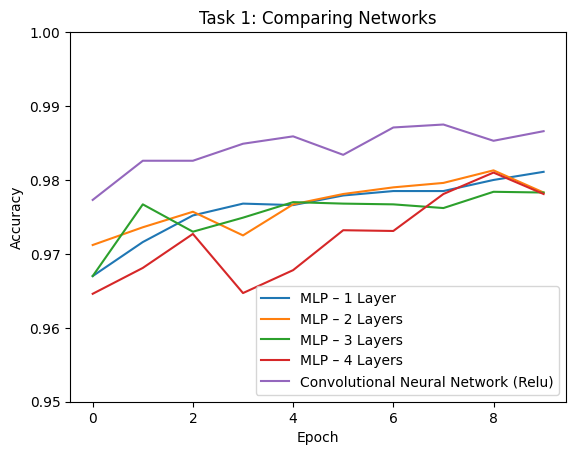

In [14]:
plt.plot(accuracy_scores[0], label='MLP – 1 Layer')
plt.plot(accuracy_scores[1], label='MLP – 2 Layers')
plt.plot(accuracy_scores[2], label='MLP – 3 Layers')
plt.plot(accuracy_scores[3], label='MLP – 4 Layers')
plt.plot(accuracy_scores['relu'], label='Convolutional Neural Network (Relu)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.95, 1.0])
plt.legend(loc='lower right')
plt.title('Task 1: Comparing Networks')

It is fairly obvious from the graph that the CNN model performed significantly better than the simple MLP networks. However, the difference between the different MLP models with different numbers of layers is more-negligible with some networks performing better than others – likely due to overfitting under certain conditions. However, it is worth noting that the ease of training a simple MLP model in terms of computational efficiency is remarkable, making it something to seriously consider under certain circumstances.

### Task 2: Comparing Activation Functions

Another task that we were assigned to do was test out a different activation function – namely the Sigmoid function – for the CNN model. To do this, I replaced the `activation` parameter in each of the layers, creating and training a different model in the process.

In [15]:
sigmoid = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='sigmoid'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='sigmoid'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='sigmoid'),
    layers.Flatten(),
    layers.Dense(64, activation='sigmoid'),
    layers.Dense(10)
])

sigmoid.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
sigmoid.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

sigmoid_results = sigmoid.fit(x_train, y_train, epochs=10,
                    validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7239 - loss: 0.8752 - val_accuracy: 0.9814 - val_loss: 0.0716
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9801 - loss: 0.0722 - val_accuracy: 0.9882 - val_loss: 0.0422
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9870 - loss: 0.0457 - val_accuracy: 0.9889 - val_loss: 0.0367
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9900 - loss: 0.0335 - val_accuracy: 0.9888 - val_loss: 0.0366
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9920 - loss: 0.0269 - val_accuracy: 0.9880 - val_loss: 0.0363
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9933 - loss: 0.0222 - val_accuracy: 0.9899 - val_loss: 0.0328
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9952 - loss: 0.0172 - val_accuracy: 0.9902 - val_loss: 0.0292
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9953 - loss: 0

In [17]:
accuracy_scores['sigmoid'] = sigmoid_results.history['val_accuracy']
pd.DataFrame(accuracy_scores)

,0,1,2,3,relu,sigmoid
0,0.9670,0.9712,0.9670,0.9646,0.9773,0.9814
1,0.9716,0.9736,0.9767,0.9681,0.9826,0.9882
2,0.9752,0.9757,0.9730,0.9727,0.9826,0.9889
3,0.9768,0.9725,0.9749,0.9647,0.9849,0.9888
4,0.9766,0.9767,0.9770,0.9678,0.9859,0.9880
5,0.9779,0.9781,0.9768,0.9732,0.9834,0.9899
6,0.9785,0.9790,0.9767,0.9731,0.9871,0.9902
7,0.9785,0.9796,0.9762,0.9781,0.9875,0.9886
8,0.9800,0.9813,0.9784,0.9810,0.9853,0.9881
9,0.9811,0.9783,0.9783,0.9781,0.9866,0.9911


Text(0.5, 1.0, 'Task 2: Comparing Activation Functions')

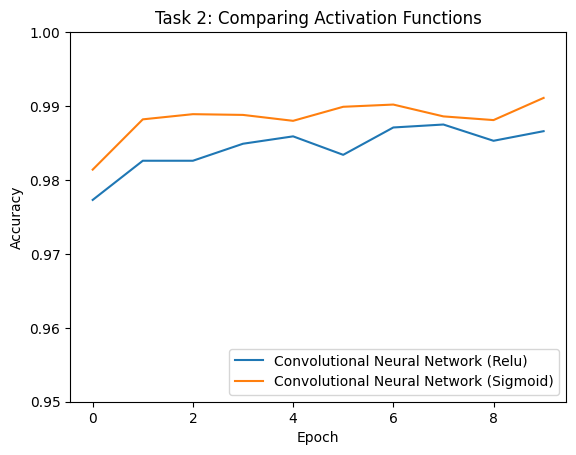

In [18]:
plt.plot(accuracy_scores['relu'], label='Convolutional Neural Network (Relu)')
plt.plot(accuracy_scores['sigmoid'], label='Convolutional Neural Network (Sigmoid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.95, 1.0])
plt.legend(loc='lower right')
plt.title('Task 2: Comparing Activation Functions')

As expected, the CNN model with the Sigmoid function performes slightly better than the one with the ReLu function, since the Sigmoid function is intended to be mathematically smoother but also more computationally intense. While it tends to be more-accurate for tasks that rely on probability estimation and binary classification, models that leverage this algorithm take longer to train than ReLu – which is generally better for problems that suffer from vanishing gradients.

### Task 3: The Value of Dropout

While I was unable to find any settings to _enable_ dropout for a specific layer using Tensorflow, there is a special layer that applies a dropout transformation to the dataset. I used this approach for Task 3 and included the documentation here for reference. I selected a value of 10% for the dropout to try and keep the effect minimal.

- [Setup Documentation for Dropout Layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout)

In [19]:
dropout_on = models.Sequential()

dropout_on.add(layers.Conv2D(32, (3, 3), activation='relu'))
dropout_on.add(layers.Dropout(0.1))
dropout_on.add(layers.MaxPooling2D((2, 2)))
dropout_on.add(layers.Conv2D(64, (3, 3), activation='relu'))
dropout_on.add(layers.Dropout(0.1))
dropout_on.add(layers.MaxPooling2D((2, 2)))
dropout_on.add(layers.Conv2D(64, (3, 3), activation='relu'))
dropout_on.add(layers.Dropout(0.1))

dropout_on.add(layers.Flatten())
dropout_on.add(layers.Dense(64, activation='relu'))
dropout_on.add(layers.Dense(10))

dropout_on.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
dropout_on.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

dropout_on_results = dropout_on.fit(x_train, y_train, epochs=100,
                    validation_data=(x_test, y_test))

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8627 - loss: 0.8452 - val_accuracy: 0.9747 - val_loss: 0.0850
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9759 - loss: 0.0799 - val_accuracy: 0.9834 - val_loss: 0.0558
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9815 - loss: 0.0614 - val_accuracy: 0.9834 - val_loss: 0.0549
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9839 - loss: 0.0528 - val_accuracy: 0.9840 - val_loss: 0.0475
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9878 - loss: 0.0428 - val_accuracy: 0.9876 - val_loss: 0.0430
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9881 - loss: 0.0394 - val_accuracy: 0.9879 - val_loss: 0.0384
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9882 - loss: 0.0392 - val_accuracy: 0.9872 - val_loss: 0.0459
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9894 -

Similar to my approach for the 10-epoch model evaluation, I created a special dictionary just for Task 3 that contained only the 100-epoch model results.

In [21]:
dropout_scores = dict()

In [22]:
dropout_scores['dropout_on_train'] = dropout_on_results.history['accuracy']
dropout_scores['dropout_on_test'] = dropout_on_results.history['val_accuracy']
pd.DataFrame(dropout_scores)

,dropout_on_train,dropout_on_test
0,0.936050,0.9747
1,0.977133,0.9834
2,0.981633,0.9834
3,0.983900,0.9840
4,0.986950,0.9876
...,...,...
95,0.994217,0.9903
96,0.995100,0.9893
97,0.994167,0.9890
98,0.993617,0.9905


Although I already trained a model with dropout turned off (the original `relu` model), I needed to create another one to demonstrate the 100-epoch training:

In [23]:
dropout_off = models.Sequential()

dropout_off.add(layers.Conv2D(32, (3, 3), activation='relu'))
dropout_off.add(layers.MaxPooling2D((2, 2)))
dropout_off.add(layers.Conv2D(64, (3, 3), activation='relu'))
dropout_off.add(layers.MaxPooling2D((2, 2)))
dropout_off.add(layers.Conv2D(64, (3, 3), activation='relu'))

dropout_off.add(layers.Flatten())
dropout_off.add(layers.Dense(64, activation='relu'))
dropout_off.add(layers.Dense(10))

dropout_off.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
dropout_off.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

dropout_off_results = dropout_off.fit(x_train, y_train, epochs=100,
                    validation_data=(x_test, y_test))

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8820 - loss: 0.8513 - val_accuracy: 0.9786 - val_loss: 0.0698
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9802 - loss: 0.0660 - val_accuracy: 0.9855 - val_loss: 0.0486
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9858 - loss: 0.0487 - val_accuracy: 0.9812 - val_loss: 0.0675
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9871 - loss: 0.0418 - val_accuracy: 0.9853 - val_loss: 0.0480
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9894 - loss: 0.0333 - val_accuracy: 0.9798 - val_loss: 0.0787
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9911 - loss: 0.0292 - val_accuracy: 0.9813 - val_loss: 0.0699
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9901 - loss: 0.0316 - val_accuracy: 0.9850 - val_loss: 0.0668
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9930 - loss: 

In [25]:
dropout_scores['dropout_off_train'] = dropout_off_results.history['accuracy']
dropout_scores['dropout_off_test'] = dropout_off_results.history['val_accuracy']
pd.DataFrame(dropout_scores)

,dropout_on_train,dropout_on_test,dropout_off_train,dropout_off_test
0,0.936050,0.9747,0.946483,0.9786
1,0.977133,0.9834,0.981017,0.9855
2,0.981633,0.9834,0.985117,0.9812
3,0.983900,0.9840,0.987533,0.9853
4,0.986950,0.9876,0.989083,0.9798
...,...,...,...,...
95,0.994217,0.9903,0.997950,0.9899
96,0.995100,0.9893,0.997967,0.9891
97,0.994167,0.9890,0.998367,0.9881
98,0.993617,0.9905,0.998333,0.9887


Text(0.5, 1.0, 'Task 3: The Value of Dropout')

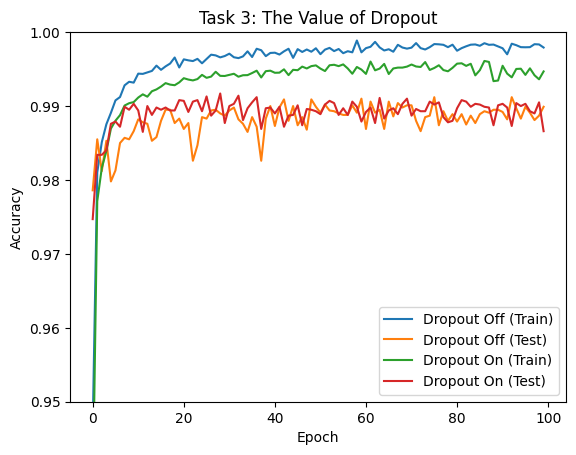

In [26]:
plt.plot(dropout_scores['dropout_off_train'], label='Dropout Off (Train)')
plt.plot(dropout_scores['dropout_off_test'], label='Dropout Off (Test)')
plt.plot(dropout_scores['dropout_on_train'], label='Dropout On (Train)')
plt.plot(dropout_scores['dropout_on_test'], label='Dropout On (Test)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.95, 1.0])
plt.legend(loc='lower right')
plt.title('Task 3: The Value of Dropout')

As can be seen in the graph above, there does seem to be some degree of overfitting with the performance of training vs testing datasets. Meanwhile, when drop-off is _enabled_, there seems to be slightly better performance relative to the training performance. This would make sense, since dropout is a regularization approach commonly used in deep learning networks that randomly disconnects some neurons between layers to prevent too much emphasis being placed on specific features. I included an article that helped me understand this better.

- [GeeksForGeeks Explanation on Dropout Regularization](https://www.geeksforgeeks.org/deep-learning/dropout-regularization-in-deep-learning/)

### Task 4: Personal Handwriting Evaluation

- [Setup Documentation for Image Files](https://www.tensorflow.org/tutorials/load_data/images)

In [27]:
class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [28]:
base_dir = './handwritten_digits_sam'

# The default settings for the images
batch_size = 30
img_height = 148
img_width = 163

# Customized height and width to allow the new unseen data to properly predict against the trained model
img_height = img_width = 28

handwritten_digits = tf.keras.utils.image_dataset_from_directory(
  base_dir,
  seed=42,
  color_mode='grayscale',
  image_size=(img_height, img_width),
  batch_size=batch_size
)

Found 30 files belonging to 10 classes.


2025-12-04 22:17:54.475363: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


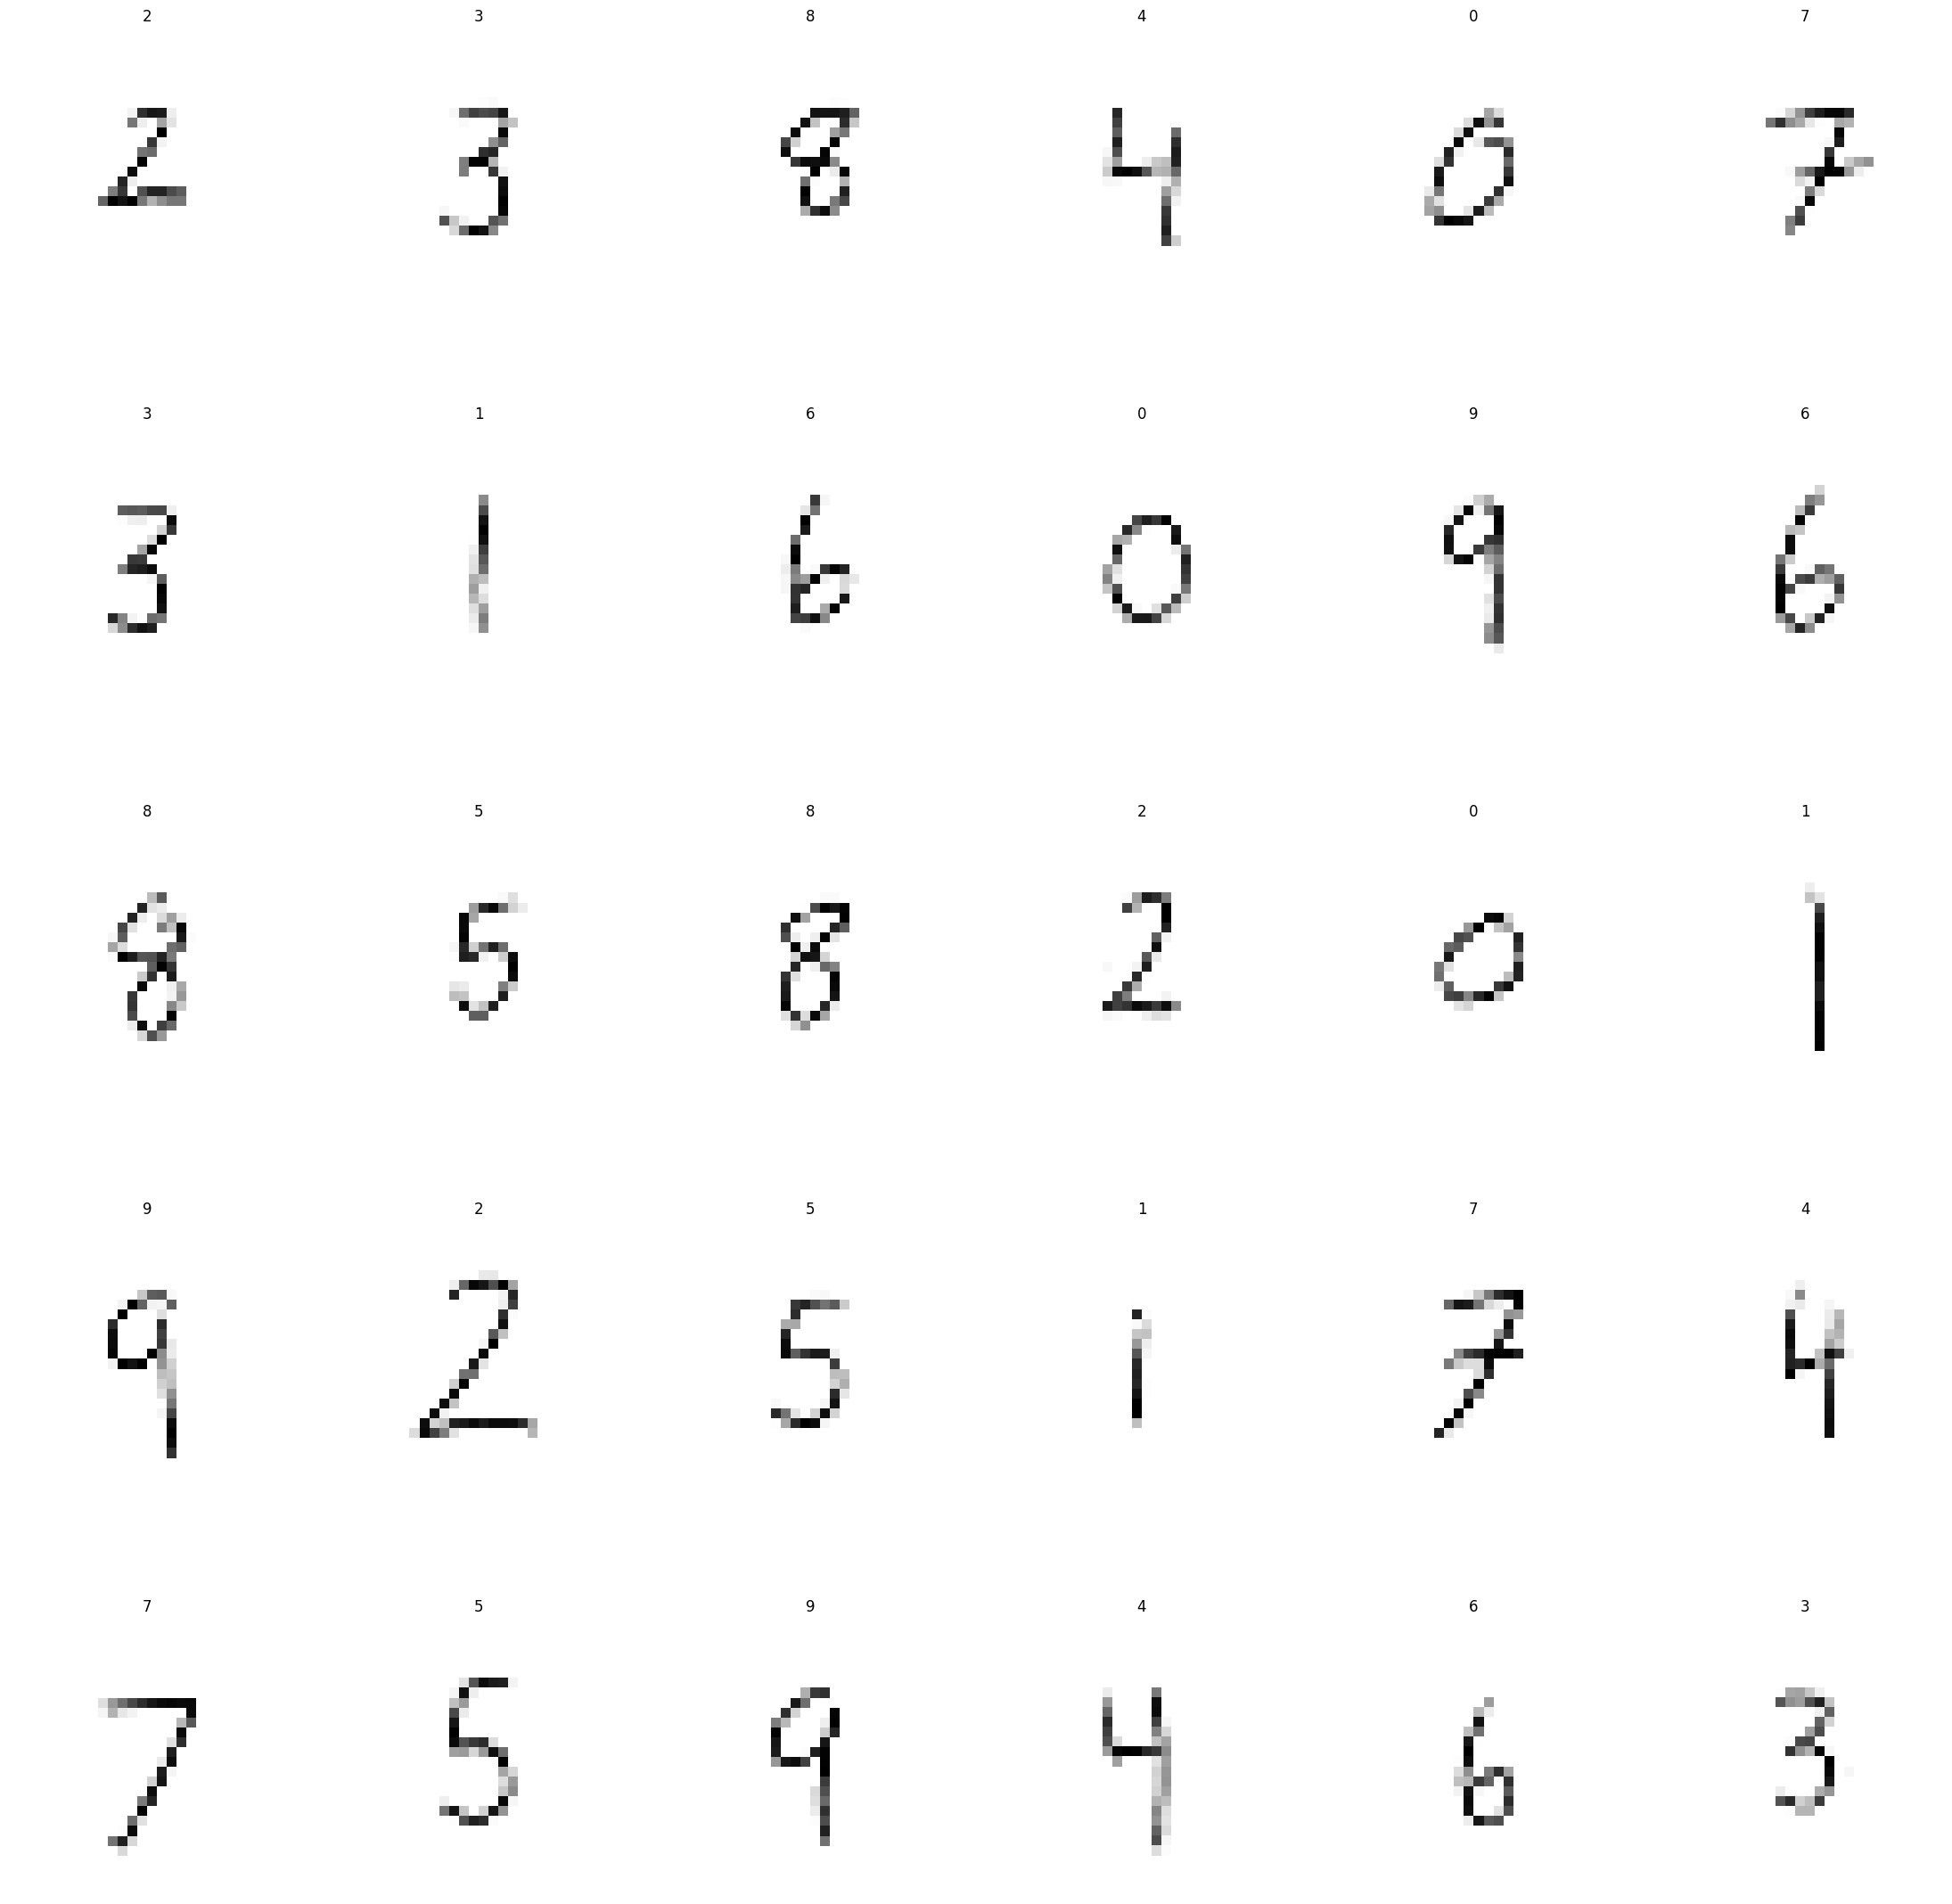

In [29]:
plt.figure(figsize=(28, 28))
for images, labels in handwritten_digits:
  for i in range(batch_size):
    ax = plt.subplot(5, 6, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"), cmap='gray')
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [47]:
handwritten_digits_images = []
handwritten_digits_labels = []

for image, label in handwritten_digits:
    handwritten_digits_images.append(image)
    handwritten_digits_labels.append(label)

handwritten_digits_images = np.array(handwritten_digits_images, dtype=np.float32)

handwritten_digits_mean = handwritten_digits_images.mean()
handwritten_digits_std = handwritten_digits_images.std()

if handwritten_digits_std == 0:
    handwritten_digits_std = 1.0

handwritten_digits_images = (handwritten_digits_images - handwritten_digits_mean) / handwritten_digits_std

print(f"Mean of X_train after scaling: {handwritten_digits_images.mean():.4f}") # Should be close to 0
print(f"Std Dev of X_train after scaling: {handwritten_digits_std.std():.4f}") # Should be close to 1

print(f"Shape of handwritten_digits before reshaping: {handwritten_digits_images.shape}")
handwritten_digits_images = handwritten_digits_images.reshape(-1, 28, 28, 1)
print(f"Shape of handwritten_digits after reshaping: {handwritten_digits_images.shape}")

Mean of X_train after scaling: -0.0000
Std Dev of X_train after scaling: 0.0000
Shape of handwritten_digits before reshaping: (1, 30, 28, 28, 1)
Shape of handwritten_digits after reshaping: (30, 28, 28, 1)


In [43]:
handwritten_digits_results = dropout_off.predict(handwritten_digits_images)
handwritten_digits_pred = tf.argmax(handwritten_digits_results, axis=1).numpy()

accuracy = np.mean(handwritten_digits_pred == handwritten_digits_images)
print(f"Accuracy: {accuracy:.4f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Accuracy: 0.0000%


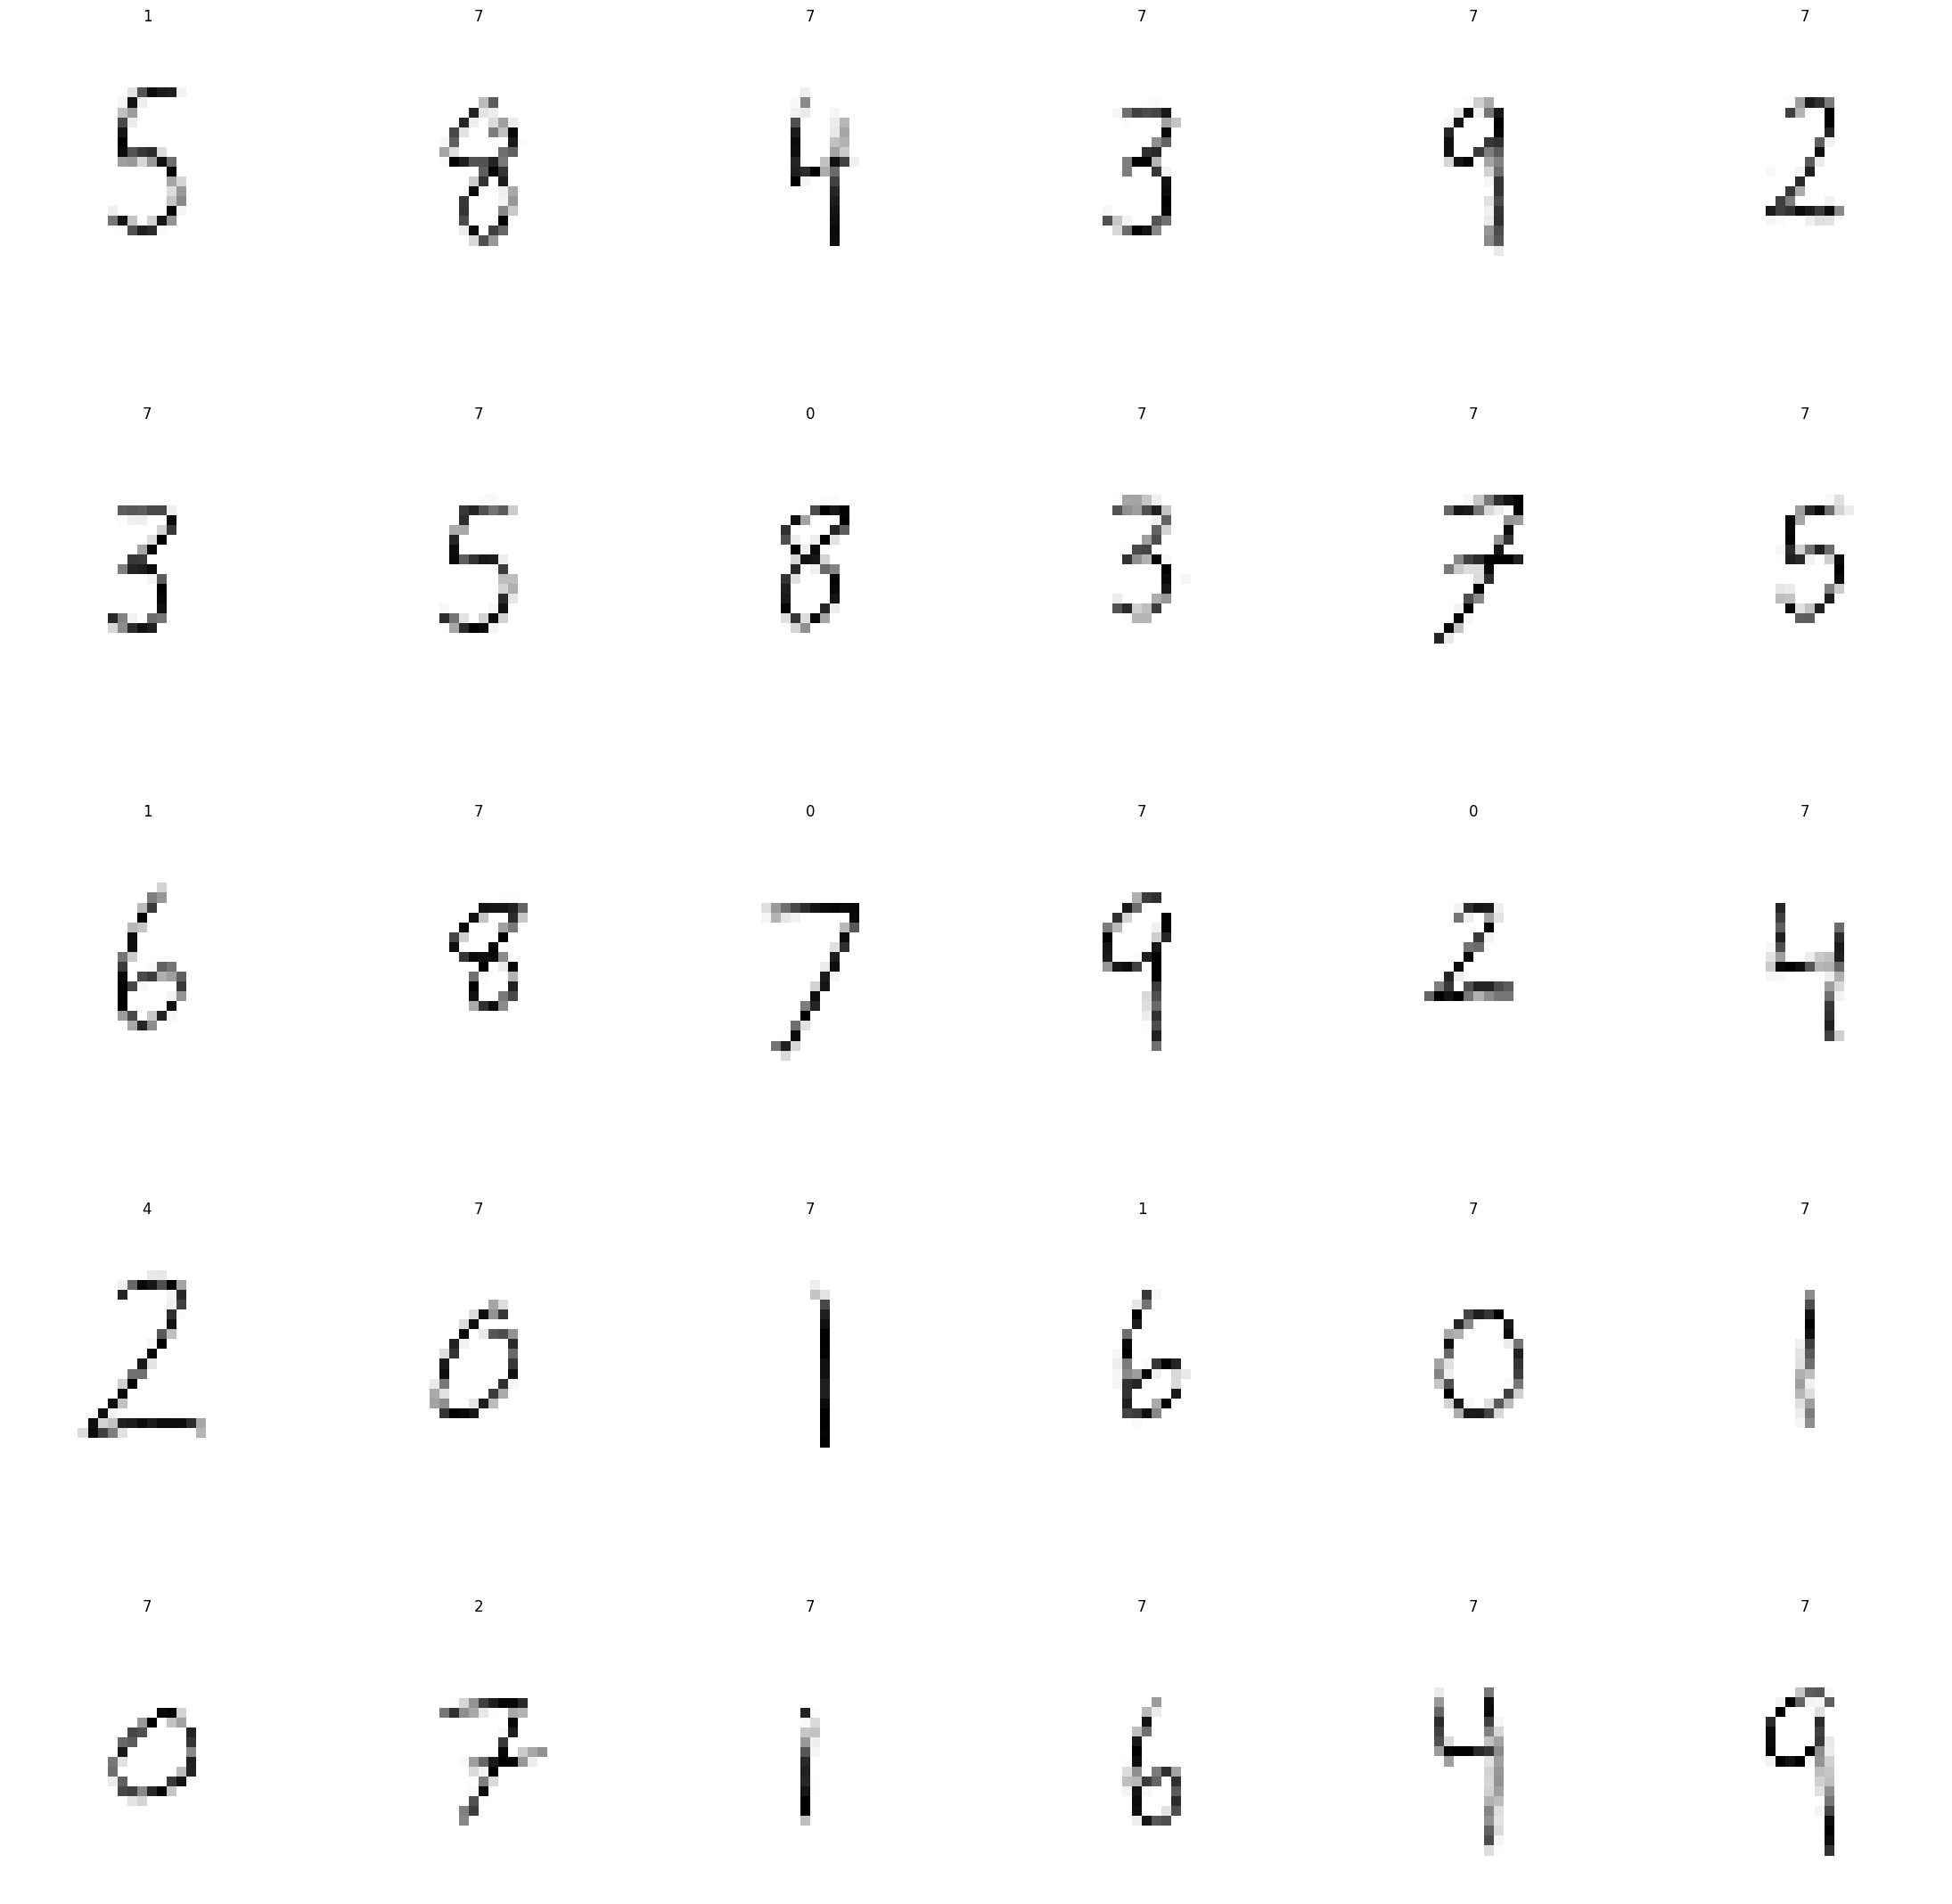

In [44]:
plt.figure(figsize=(28, 28))
for images, labels in handwritten_digits:
  for i in range(batch_size):
    ax = plt.subplot(5, 6, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"), cmap='gray')
    plt.title(class_names[handwritten_digits_pred[i]])
    plt.axis("off")